# <b>Assignment 3: Convolutional Neural Network (CNN) Network</b>

# **Group:** Bone Fracture Dataset

# **Contributors**
1. Allison Young
2. Laura Telle
3. Vanessa Lukasser

# Tasks

1. **Load preprocessed data from Assignment 1**
   - **Time series:** Extract data windows based on annotations or a fixed window length, then resample signals to a uniform window length.
   - **Image:** Apply augmentation when loading data into a PyTorch Dataset.

2. **Build, train, and evaluate a network**
   - **Time series:** 
     - Build your own CNN model and justify your design choices — explain why you selected **a fixed or varying kernel size** and whether you used **1D or 2D convolutions**.
     - Describe what you observed in your data that informed the model architecture.
   - **Image:** Build two CNN-based models:
     - One using **transfer learning**.
     - One built **from scratch** as a plain CNN or with residual blocks.
     - Compare the performance of both models and explain why one outperforms the other.
   - Examine the learning curves — identify any issues and describe how you addressed them.
   - Interpret the evaluation results — assess model performance and suggest potential improvements.
   - Inspect the misclassified samples and describe what might be causing the errors.

## Packages

In [21]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torchinfo import summary
import torchvision.models as models
import torch.optim as optim
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
from sklearn.model_selection import KFold

Checks if graphics card is available

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Set a random seed to ensure reproduceability within the notebook

In [23]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed(42)

## Functions

In [24]:
def train_Model(dl_train, dl_val, model, epochs, criterion, optimizer, device, patience= 10):

    model.to(device)

    train_losses= []
    validation_losses= []

    best_val_loss    = float('inf')   # track best validation loss seen so far
    patience_counter = 0              # count epochs without improvement
    best_model_state = None           # save weights of the best model

    for epoch in range(epochs): #iterating through epochs

        #Training
        model.train() #set model to training state

        running_loss= 0 
        total= 0

        for x_batch, y_batch in dl_train: #iterating through batches provided by dataloader

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad() #set gradients to zero
            y_pred= model(x_batch) #calculate prediction
            loss= criterion(y_pred, y_batch) #calculate cross entropy loss
            loss.backward() #backpropagation: calculating the gradients
            optimizer.step() #Updating weights and biases based on gradients

            running_loss+= loss.item() #add batch loss to running loss
            total += x_batch.size(0)
        
        train_losses.append(running_loss/total) #average training loss of epoch

        #Validation
        model.eval() #set model to evaluation mode

        val_loss=0
        total_val= 0

        with torch.no_grad(): #deactivates gradient calculation 
            for x_batch, y_batch in dl_val: #iterating through batches provided by dataloader
                
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred= model(x_batch) #calculate prediction
                loss= criterion(y_pred, y_batch) #calculate cross entropy loss

                val_loss += loss.item() #add batch loss to running val loss
                total_val+= x_batch.size(0)

            validation_losses.append(val_loss/total_val) #average validation loss of epoch

        #print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_losses[-1]:.4f} - Val Loss: {validation_losses[-1]:.4f}")
            
        # --- Early Stopping ---
        if  (val_loss/total_val) < best_val_loss:
            best_val_loss    = (val_loss/total_val)
            patience_counter = 0
            best_model_state = model.state_dict().copy()   # save best weights
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1} — no improvement for {patience} epochs.")
                break
    model.load_state_dict(best_model_state)  
            
    return train_losses, validation_losses

In [25]:
def evaluate_Model(dl_test, model, criterion, device):

    model.eval() #set model to evaluation mode
    model.to(device)
      
    test_loss= 0.0
    total= 0
    correct= 0

    all_preds= []
    all_labels= []
        
    with torch.no_grad(): #deactivates gradient calculation
        
        for x_batch, y_batch in dl_test: #iterating through batches provided by dataloader
            
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred= model(x_batch) #calculate prediction
            loss= criterion(y_pred, y_batch) #calculate loss
            test_loss+= loss.item() #add batch loss to total test loss

            y_pred= torch.argmax(y_pred, dim=1) #get predicted class from pred. logits

            total+= y_pred.size(0)
            correct += (y_pred == y_batch).sum().item() #number of correct predictions

            all_preds.extend(y_pred.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    final_loss = test_loss / len(dl_test) #test loss

    #--- Performance Metrics ---
    accuracy = (correct / total) * 100 
    precision= precision_score(all_labels, all_preds)*100
    recall= recall_score(all_labels, all_preds)*100
    f1= f1_score(all_labels, all_preds)*100
    
    print(f"--- TEST RESULTS ---")
    print(f"Test Loss: {final_loss:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Test Precision: {precision:.2f}%")
    print(f"Test Recall: {recall:.2f}%")
    print(f"Test F1 Score: {f1:.2f}%")
    
    return final_loss, accuracy, precision, recall, f1, all_labels, all_preds

In [26]:
def show_learn_curves(train_losses, val_losses):
    
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label='Train loss')
    plt.plot(epochs, val_losses,   label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

In [27]:
def plot_confusion_matrix(true_labels, predicted_labels, class_names=None):
    
    cm = confusion_matrix(true_labels, predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    report_train = classification_report(true_labels, predicted_labels, target_names=class_names)

    # Confusion Matrix
    fig, axs = plt.subplots(2, 1, figsize=(8, 6),)
    disp.plot(ax=axs[0], cmap="Blues", values_format="d")

    # Report
    axs[1].axis("off")
    axs[1].text(0, 0.5, report_train, fontsize=10, fontfamily="monospace")
    
    plt.tight_layout()
    plt.show()

In [28]:
def show_misclassifications(model, data_loader, device, class_names, n=8):
    model.eval()

    misclassified = []   # store (image, true_label, pred_label) for wrong predictions

    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            preds   = torch.argmax(outputs, dim=1)   # predicted class index

            # find misclassified indices in this batch
            wrong = (preds != y).nonzero(as_tuple=True)[0]
            for idx in wrong:
                misclassified.append((
                    x[idx].cpu(),       # image tensor (3, H, W)
                    y[idx].item(),      # true label
                    preds[idx].item()   # predicted label
                ))

    if len(misclassified) == 0:
        print("No misclassifications found.")
        return

    # randomly select n samples from all misclassified
    import random
    selected = random.sample(misclassified, min(n, len(misclassified)))

    # plot
    cols = 4
    rows = (len(selected) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for i, (img, true, pred) in enumerate(selected):
        img_np = img.permute(1, 2, 0).numpy()   # (3,H,W) → (H,W,3) for matplotlib
        axes[i].imshow(img_np)
        axes[i].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}", fontsize=8, color='red')
        axes[i].axis('off')

    for i in range(len(selected), len(axes)):   # hide unused subplots
        axes[i].axis('off')

    plt.suptitle(f"Random Misclassifications ({len(misclassified)} total)", fontsize=11)
    plt.tight_layout()
    plt.show()

## Load preprocessed Dataset

The dataset consists of 108 bone images used for fracture detection, organized into two distinct folders based on their condition:

- Normal: 77 images of healthy bones
- Fractured: 31 images of fractured bones

The images are preprocessed and share a standardized resolution of $224 \times 224$ pixels. In this initial phase, the images are loaded from their respective directories into the script.

In [29]:
#Define Data Paths
Data= Path(Path.cwd()/"Data")
Fractures = Data/"CleanedFractures"
Normals= Data/"CleanedNormals"

### Sample Images

Text(0.5, 1.0, 'fracture_1146')

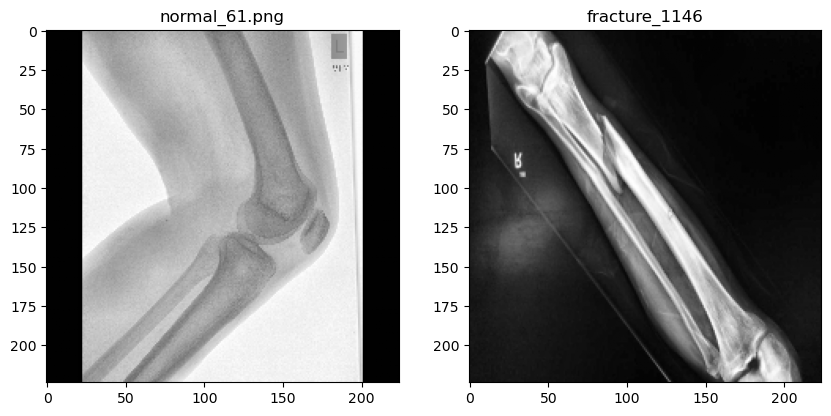

In [30]:
fig = plt.figure(figsize=(10, 7))

img1= np.asanyarray(Image.open(Normals/"normal_61.png").convert("L"))
img2= np.asanyarray(Image.open(Fractures/"fracture_1146.png").convert("L"))

plt.subplot(1,2,1)
plt.imshow(img1, cmap="gray")
plt.title("normal_61.png")
plt.subplot(1,2,2)
plt.imshow(img2, cmap="gray")
plt.title("fracture_1146")

The script iterates through both folder directories to collect all image file paths into a single list. Also, it generates a corresponding list of binary labels ($0$ for normal, $1$ for fracture) by checking the filename of each image.

In [31]:
files= [] #empty list to store filepaths

#Get "Fracture" paths
for dir in Fractures.iterdir():
    files.append(dir)

#Get "Normals" paths
for dir in Normals.iterdir():
    files.append(dir)

# Extract labels from filenames
labels= [1 if "fracture" in i.name else 0 for i in files]

print(f"Number of files {len(files)} | Number of labels {len(labels)}")

Number of files 108 | Number of labels 108


## Data Split

Next, the data is splitted. An independent test set is set aside, while the remaining data is reserved for the K-Fold process. This ensures that a portion of the data remains completely unseen for a final, unbiased evaluation, while the rest is used to rigorously fine-tune and validate the model.

In [32]:
X_work, X_test, y_work, y_test = train_test_split(
    files, labels, test_size=0.2, random_state=42, stratify=labels
)

## Build Custom Dataset

In the next step, a custom PyTorch Dataset class is implemented, utilizing the standard len and getitem methods to automatically load images and convert them into PyTorch tensors. This structures the data into a format PyTorch understands, enabling the use of DataLoader components for efficient batching and shuffling during training.

Additionally, data augmentation techniques are integrated into the dataset pipeline to enhance model robustness and prevent overfitting. Because these transformations are applied within the getitem method, a new randomized variation of the images is generated at every epoch, providing the model with different training variations throughout the process. Furthermore, Resize transformation to $224 \times 224$ pixels was included. While the source images are expected to be in the correct resolution, this serves as a necessary safeguard to ensure that every input consistently matches the fixed dimensions required by the VGG-16 architecture.

In [33]:
class CustomDataset(Dataset):
    def __init__(self, files, labels, augment= False):
        self.data = files
        self.labels = labels

        aug_transforms = [
            transforms.RandomHorizontalFlip(),                   # randomly flip image left-right
            transforms.RandomVerticalFlip(p=0.2),                # randomly flip image upside down
            transforms.RandomRotation(degrees= 15),              # randomly rotate up to ±15 degrees
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Randomly zoom in and out
            transforms.ColorJitter(brightness=0.2, contrast=0.2),# Add brightness and contrast variations 
        ] if augment else []

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),       # match with ImageNet resolution
            *aug_transforms,
            transforms.ToTensor(),               # converts uint8 [0,255] → float32 [0,1] (MinMax normalization)
            transforms.Normalize(mean=[0.485, 0.456, 0.406], #Normalize values for pretrained Model
                                std =[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)  
        label = self.labels[idx]
        label= torch.tensor(label, dtype= torch.long)

        return image, label


## Dataloaders

Next the dataloader for the test set is created choosing a batch_size of 32. The dataloaders for the train and validation dataset are created during the K-Fold Loop.

In [34]:
batch_size= 32

dataset_test= CustomDataset(X_test, y_test, augment=False)
dataloader_test= DataLoader(dataset=dataset_test, batch_size=batch_size, shuffle= False )

## Transfer Learning- VGG-Net 

Transfer learning uses pre-trained models, such as VGG-16, which have already learned to identify complex features from the massive ImageNet dataset. By utilizing these existing weights and biases as a foundation, this approach significantly accelerates the training process and improves performance on smaller datasets.

To train the VGGNet model, hyperparameters such as the number of epochs, the optimizer, the loss function, and the learning rate must be defined. These settings determine how the model learns from the data and are important for balancing training speed with model accuracy. The code performs 5-Fold Cross-Validation to ensure a reliable evaluation of the model. In each of the five cycles, the training data is split into new, unique training and validation sets, forcing the model to be tested on different portions of the data every time. By creating fresh DataLoader instances in every loop, the process prevents bias and ensures the model is not just memorizing a single data split. This approach should provide a much better accuracy score than a simple one-time split, which is critical for such a small dataset.


--- FOLD 1/5 ---
--> New best Fold (Avg Val Loss: 0.0045)


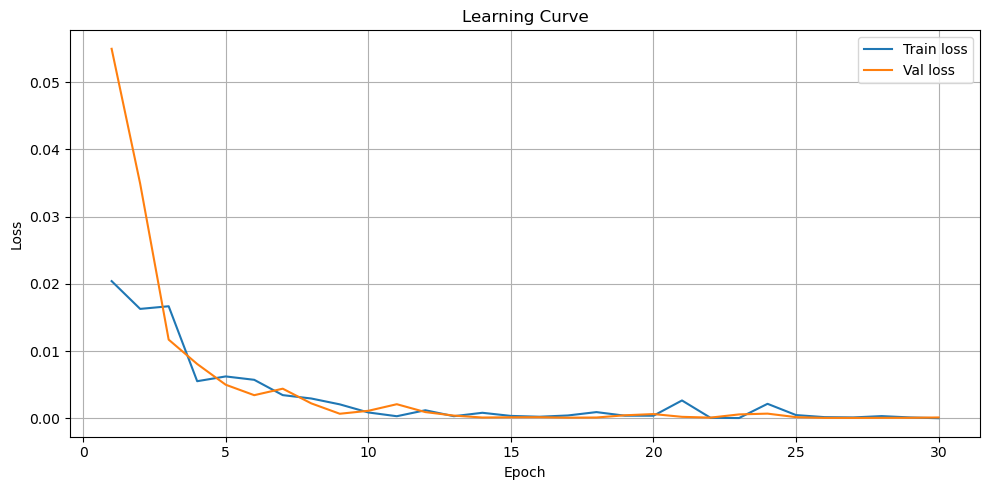


--- FOLD 2/5 ---
--> New best Fold (Avg Val Loss: 0.0031)


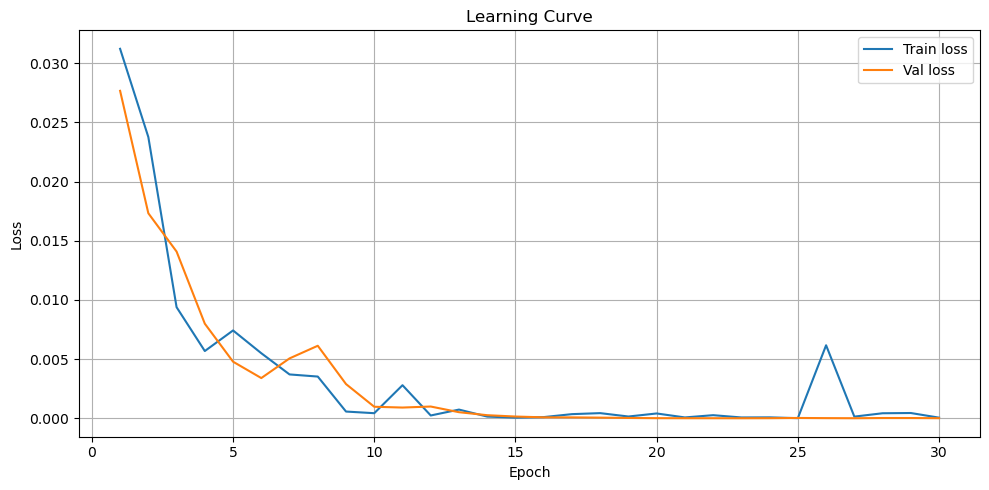


--- FOLD 3/5 ---
Early stopping at epoch 15 — no improvement for 10 epochs.


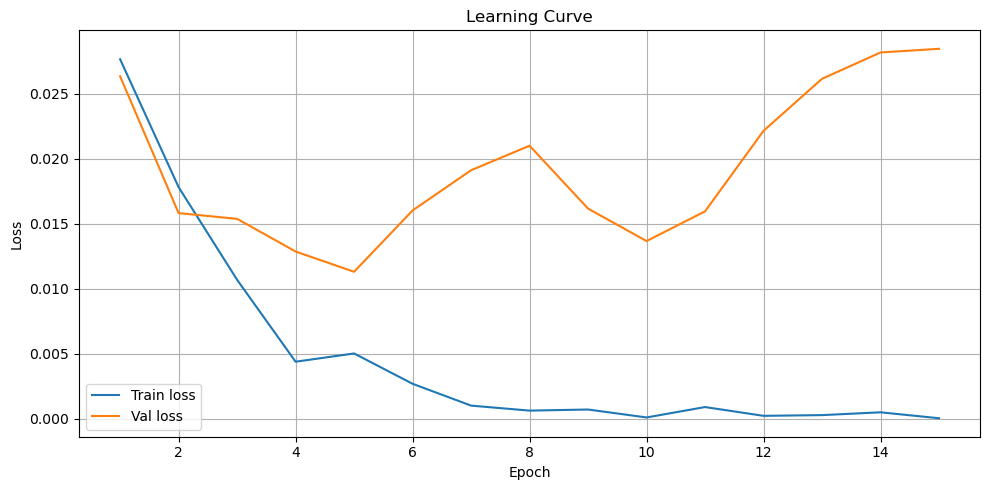


--- FOLD 4/5 ---
Early stopping at epoch 16 — no improvement for 10 epochs.


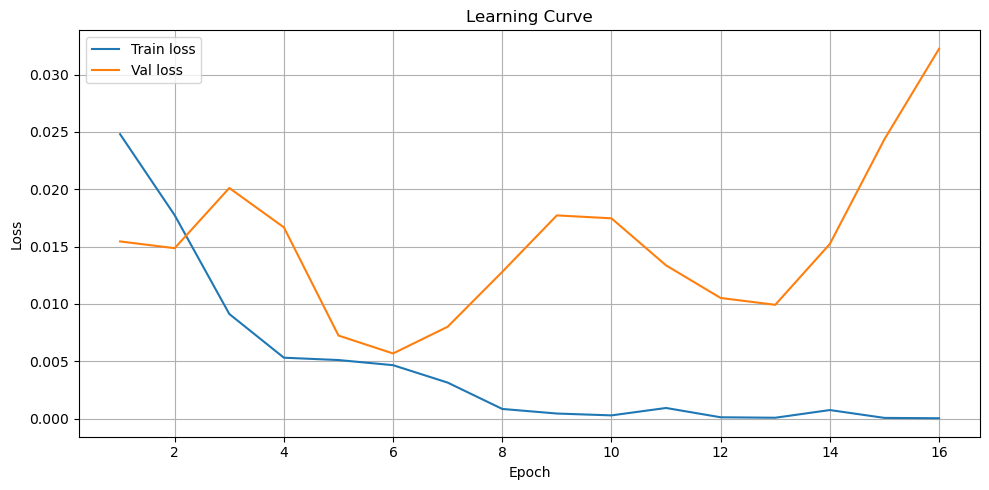


--- FOLD 5/5 ---
Early stopping at epoch 22 — no improvement for 10 epochs.


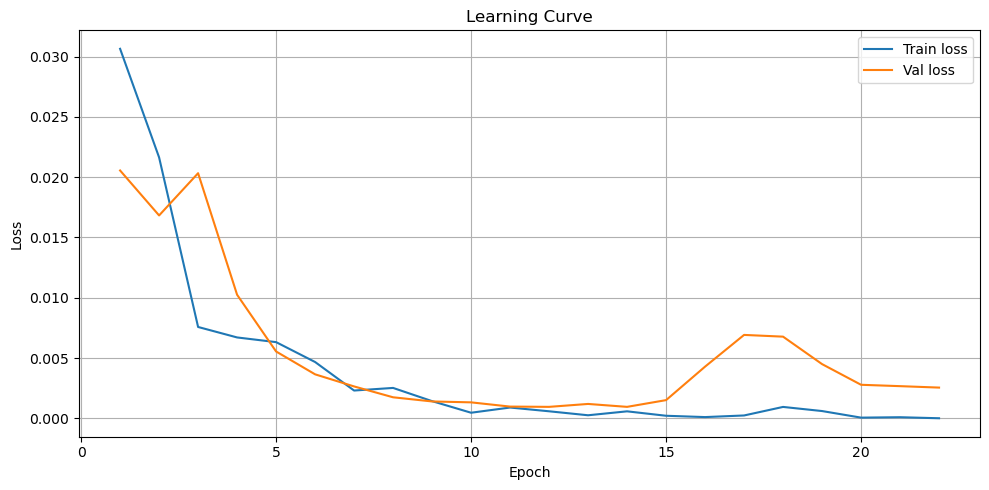

<All keys matched successfully>

In [35]:
set_seed(42)
epochs= 30


best_global_val_loss = float('inf')
best_global_model_state = None

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

X_work_arr = np.array(X_work)
y_work_arr = np.array(y_work)

fold_results_val = []
fold_results_train = []

# Training Loop
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_work_arr)):

    print(f"\n" + "="*30)
    print(f"--- FOLD {fold + 1}/5 ---")
    print("="*30)
    
    X_train_fold, X_val_fold = X_work_arr[train_idx], X_work_arr[val_idx]
    y_train_fold, y_val_fold = y_work_arr[train_idx], y_work_arr[val_idx]
    
    # Create Datasets & Dataloader
    dataset_train = CustomDataset(X_train_fold, y_train_fold, augment=True)
    dataset_val = CustomDataset(X_val_fold, y_val_fold, augment=False)
    
    dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

    # Initialize Model new for every fold
    model_vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    
    # Freeze Feature extractor
    for param in model_vgg.features.parameters():
        param.requires_grad = False
        
    # Adjust Classifier
    model_vgg.classifier[6] = nn.Linear(4096, 2)
    model_vgg = model_vgg.to(device)

    # Optimizer & Criterion
    optimizer = torch.optim.Adam(model_vgg.classifier.parameters(), lr=0.0001) #only train classifier!
    criterion = nn.CrossEntropyLoss()
    
    # Call training function
    train_loss, val_loss = train_Model(
        dl_train=dataloader_train, 
        dl_val=dataloader_val, 
        model=model_vgg, 
        epochs=epochs, 
        criterion=criterion, 
        optimizer=optimizer, 
        device=device
    )

    current_fold_avg_loss = sum(val_loss) / len(val_loss)
    
    #Evaluate Best Model
    if current_fold_avg_loss < best_global_val_loss:
        best_global_val_loss = current_fold_avg_loss
        best_global_model_state = model_vgg.state_dict().copy()
        print(f"--> New best Fold (Avg Val Loss: {best_global_val_loss:.4f})")

    show_learn_curves(train_loss, val_loss)
    
    fold_results_val.append(val_loss)
    fold_results_train.append(train_loss)

model_vgg.load_state_dict(best_global_model_state)

The 5-fold cross-validation results show that the model's performance is highly sensitive to the specific data split, which is typical for small, high-variance datasets. All folds display a sharp initial loss reduction, confirming that the pre-trained VGG-16 weights effectively extract relevant features. However, folds 3, 4, and 5 exhibit signs of overfitting after 5–10 epochs, where validation loss diverges as the model begins to memorize training samples.  This variability confirms the necessity of cross-validation to prevent bias from any single data partition. By implementing early stopping and selecting the best model state per fold, we mitigated this risk. Focusing on early training stages allowed the model to capture essential structural features without being corrupted by the noise observed in later epochs, ensuring a more generalized final model.

### Model Testing

In [36]:
final_loss, accuracy, precision, recall, f1, all_labels, all_preds  = evaluate_Model(dl_test= dataloader_test, model= model_vgg, 
                                                                                     criterion= criterion, device= device)

--- TEST RESULTS ---
Test Loss: 0.4161
Test Accuracy: 90.91%
Test Precision: 93.75%
Test Recall: 93.75%
Test F1 Score: 93.75%


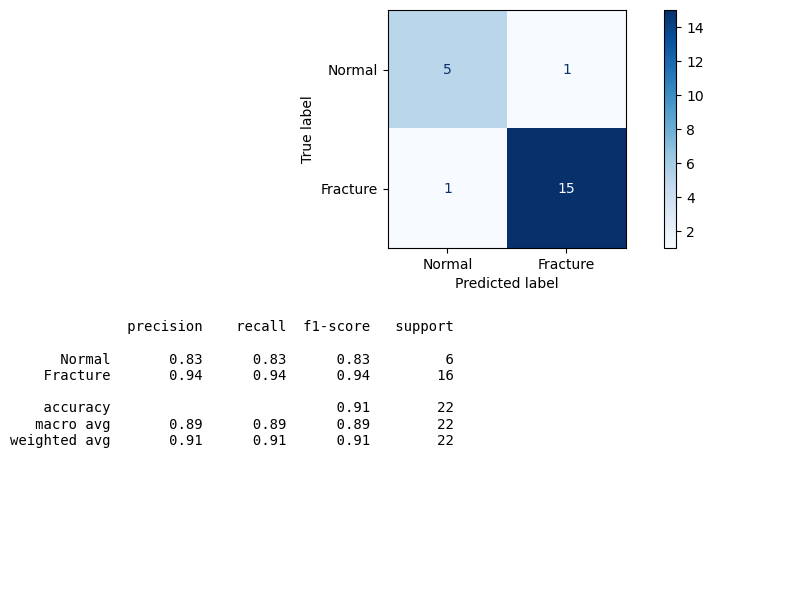

In [37]:
class_names = ['Normal', 'Fracture']
plot_confusion_matrix(true_labels=all_labels, predicted_labels=all_preds, class_names=class_names)

The model achieved good performance metrics, demonstrating strong generalization on unseen data. With only two misclassifications—one false negative and one false positive- the errors are minimal and likely stem from subtle fracture patterns or image noise. These results confirm that the pipeline, which combines transfer learning, augmentation, and cross-validation, is effective. Given the limited size of the dataset, this performance is a promising indicator of the model's diagnostic reliability. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.78217316..2.64].


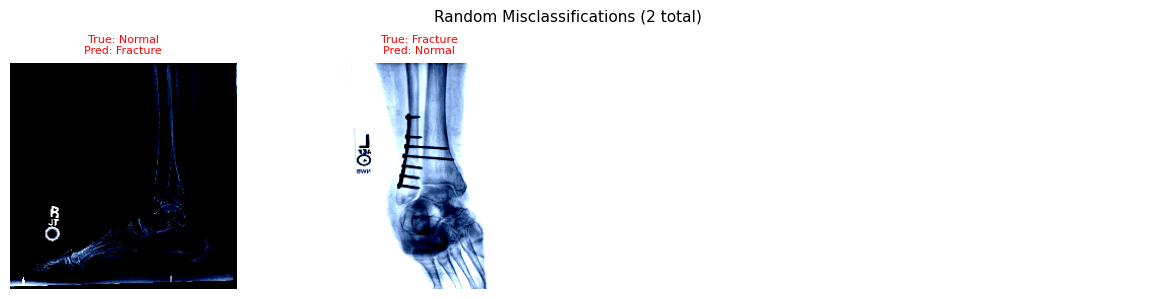

In [38]:
show_misclassifications(model=model_vgg, data_loader=dataloader_test, device=device, class_names=class_names, n=8)

The left image might be misclassified because it is too dark and blurry, making it hard for the model to see the bone clearly. The right image might be misclassified because of the metal surgical plate; since the model eventually never saw this metal fixation during training, it doesn't recognize it and gets confused.

## ResNet

The ResNet architecture, built from scratch without pre-trained weights, utilizes residual blocks across three stages to enable deep feature learning. By incorporating skip connections, this design addresses the degradation problem, allowing the model to focus on learning residual mappings that improve performance on our specific dataset.

We use 2D convolutions to preserve the spatial structure and features of the bone images. A fixed kernel size of $3 \times 3$ was selected for the residual blocks, as it is computationally efficient while allowing the network to capture fine-grained local patterns.

In [39]:
class DownSampleBlock(nn.Module):
    def __init__(self, channels, kernel_size, stride, padding):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size, stride, padding),
            nn.BatchNorm2d(channels),   # normalize after downsampling
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels,  out_channels, 3, 1, 1)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU()

        if in_channels != out_channels:
            self.residual_layer = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, 1, 0),
                nn.BatchNorm2d(out_channels),   # BN on projection shortcut
            )
        else:
            self.residual_layer = nn.Identity()

    def forward(self, x):
        residue = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + self.residual_layer(residue))


class ResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # 3 stages is enough for 224x224 input — keeps enough spatial info
        self.res1  = ResidualBlock(64, 64)
        self.down1 = DownSampleBlock(64,  4, 2, 1)   # 224→112

        self.res2  = ResidualBlock(64,  128)
        self.down2 = DownSampleBlock(128, 4, 2, 1)   # 112→56

        self.res3a = ResidualBlock(128, 256)
        self.res3b = ResidualBlock(256, 256)
        self.down3 = DownSampleBlock(256, 4, 2, 1)   # 56→28

        self.pool  = nn.AdaptiveAvgPool2d((1, 1))
        self.drop  = nn.Dropout(0.5)                 # regularization for small dataset
        self.fc    = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.down1(self.res1(x))
        x = self.down2(self.res2(x))
        x = self.down3(self.res3b(self.res3a(x)))
        x = torch.flatten(self.pool(x), 1)
        x = self.drop(x)
        return self.fc(x)

### Model Training

To train the ResNet model from scratch, we employed again 5-fold cross-validation to ensure robust evaluation and minimize overfitting on our limited dataset. The model architecture and DataLoaders are re-initialized for each fold to maintain data integrity and prevent leakage. Unlike the VGG-16 transfer learning approach, this custom architecture lacks pre-trained weights and must learn complex features from scratch. Consequently, the training process is significantly more computationally intensive as it optimizes a much larger number of parameters.


--- FOLD 1/5 ---
Early stopping at epoch 11 — no improvement for 10 epochs.
--> New best Fold (Avg Val Loss: 0.0528)


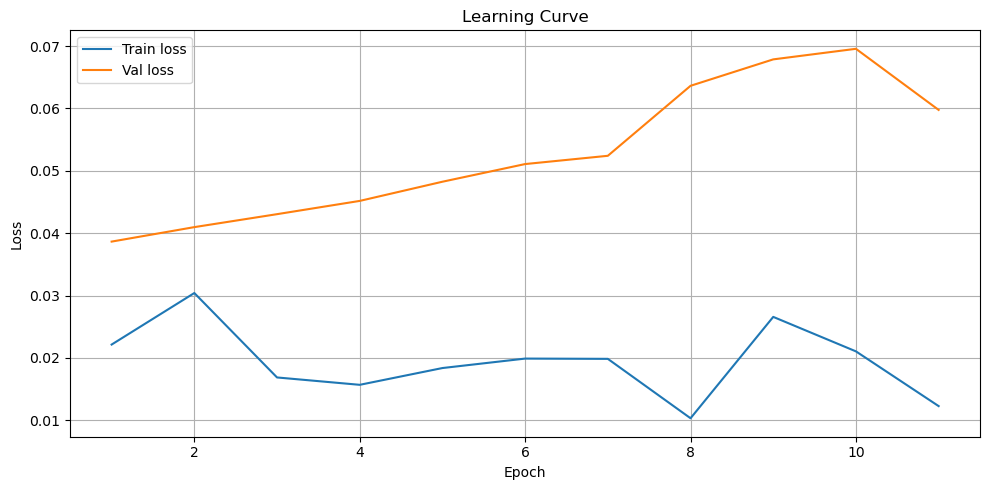


--- FOLD 2/5 ---
--> New best Fold (Avg Val Loss: 0.0181)


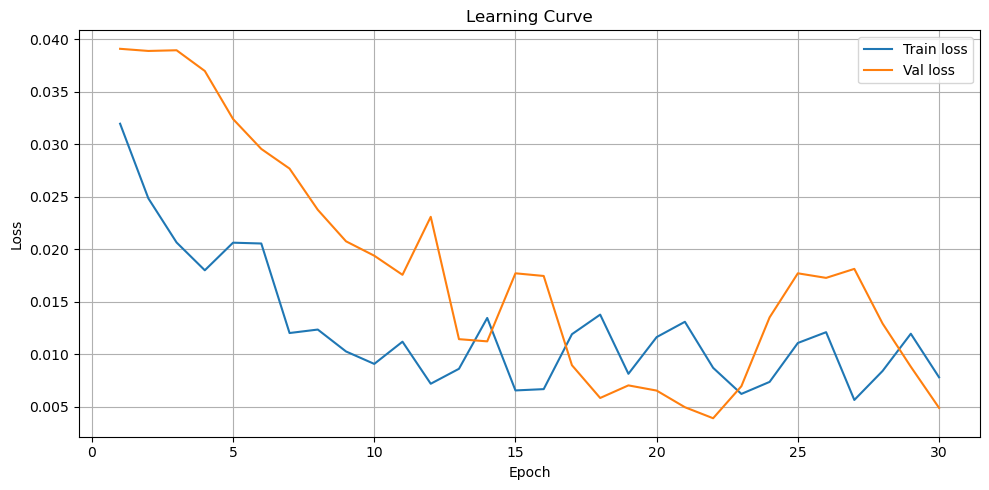


--- FOLD 3/5 ---


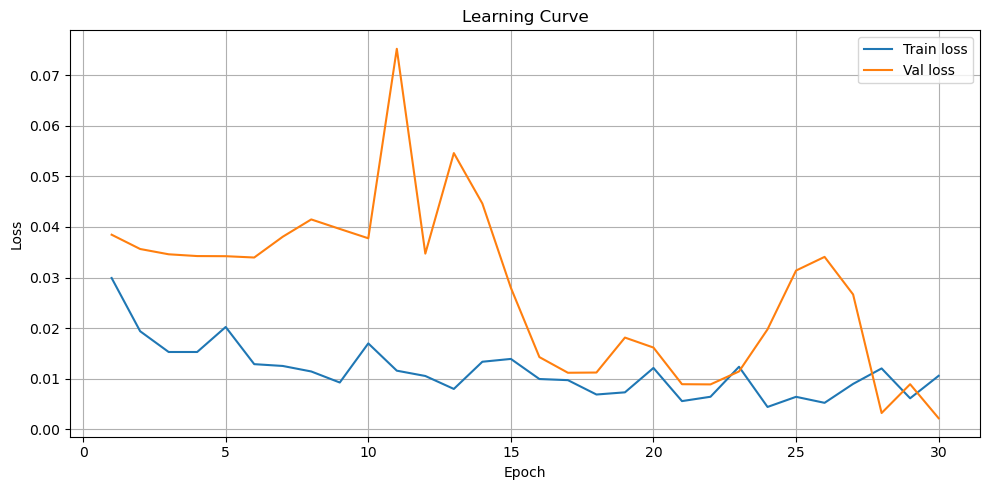


--- FOLD 4/5 ---
Early stopping at epoch 17 — no improvement for 10 epochs.


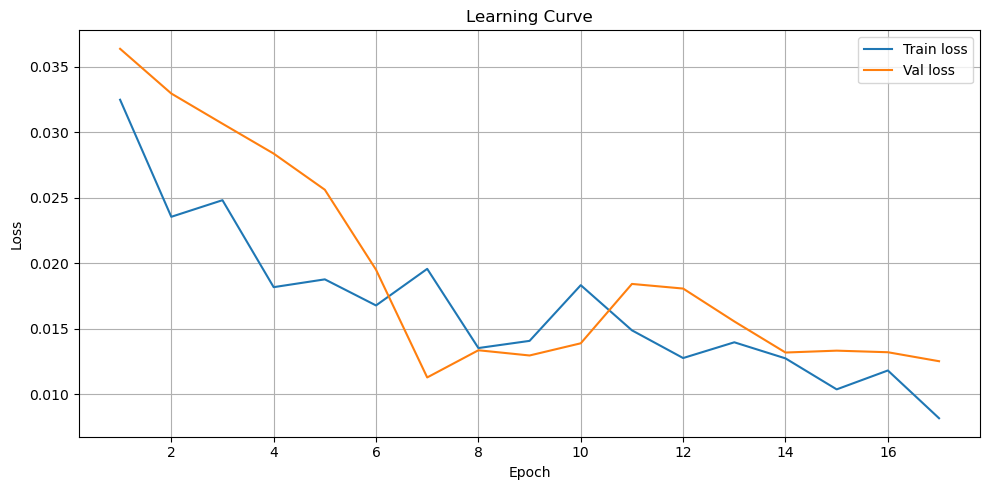


--- FOLD 5/5 ---
Early stopping at epoch 26 — no improvement for 10 epochs.


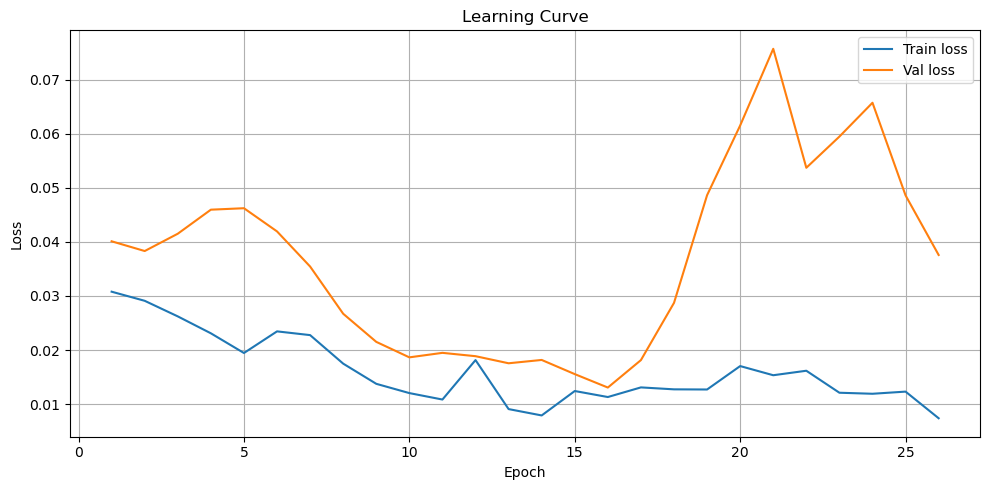

<All keys matched successfully>

In [40]:
set_seed(42)
epochs= 30

best_global_val_loss = float('inf')
best_global_model_state = None

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

X_work_arr = np.array(X_work)
y_work_arr = np.array(y_work)

fold_results_val = []
fold_results_train = []

# Training Loop
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_work_arr)):

    print(f"\n" + "="*30)
    print(f"--- FOLD {fold + 1}/5 ---")
    print("="*30)
    
    X_train_fold, X_val_fold = X_work_arr[train_idx], X_work_arr[val_idx]
    y_train_fold, y_val_fold = y_work_arr[train_idx], y_work_arr[val_idx]
    
    # Create Datasets & Dataloader
    dataset_train = CustomDataset(X_train_fold, y_train_fold, augment=True)
    dataset_val = CustomDataset(X_val_fold, y_val_fold, augment=False)
    
    dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

    # Initialize Model new for every fold
    model_resnet = ResNet(num_classes= 2).to(device)

    # Optimizer & Criterion
    optimizer = torch.optim.Adam(model_resnet.parameters(), lr=0.0001) 
    criterion = nn.CrossEntropyLoss()
    
    # Call training function
    train_loss, val_loss = train_Model(
        dl_train=dataloader_train, 
        dl_val=dataloader_val, 
        model=model_resnet, 
        epochs=epochs, 
        criterion=criterion, 
        optimizer=optimizer, 
        device=device
    )

    current_fold_avg_loss = sum(val_loss) / len(val_loss)

    if current_fold_avg_loss < best_global_val_loss:
        best_global_val_loss = current_fold_avg_loss
        best_global_model_state = model_resnet.state_dict().copy()
        print(f"--> New best Fold (Avg Val Loss: {best_global_val_loss:.4f})")

    show_learn_curves(train_loss, val_loss)
    
    fold_results_val.append(val_loss)
    fold_results_train.append(train_loss)

model_resnet.load_state_dict(best_global_model_state)

The learning curves for this ResNet model demonstrate that training from scratch on a limited dataset is inherently unstable, resulting in high sensitivity to individual data splits. The model struggles to achieve consistent convergence, as evidenced by persistent oscillations and the failure of training and validation losses to stabilize. These results highlight that the network likely lacks sufficient data to reliably extract complex structural features, causing it to oscillate or overfit on noise rather than generalizing.  Consequently, these outcomes illustrate the extreme difficulty of training deep architectures from scratch on small medical datasets without the benefit of pre-trained feature hierarchies.

### Model Testing

In [41]:
final_loss, accuracy, precision, recall, f1, all_labels, all_preds= evaluate_Model(dl_test=dataloader_test, model=model_resnet, criterion=criterion, device=device)

--- TEST RESULTS ---
Test Loss: 0.3266
Test Accuracy: 86.36%
Test Precision: 93.33%
Test Recall: 87.50%
Test F1 Score: 90.32%


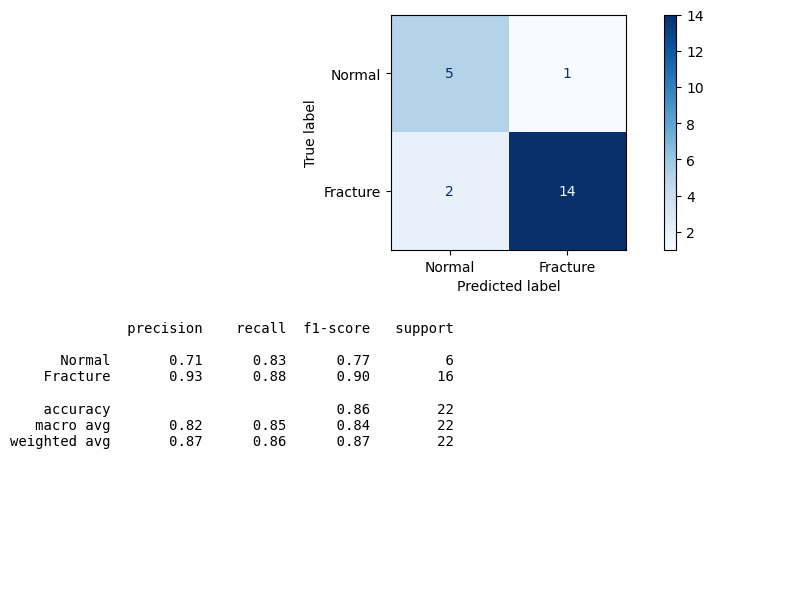

In [42]:
class_names = ['Normal', 'Fracture']
plot_confusion_matrix(true_labels=all_labels, predicted_labels=all_preds, class_names=class_names)

Despite the instability observed during training, the model achieves good performance on the test set, demonstrating that it was able to capture essential patterns. The confusion matrix confirms reliability in identifying fractures, indicating that the architecture is robust even without pre-trained weights.  These results show that while training from scratch is challenging, the residual connections provide enough structural capability to yield promising diagnostic outcomes.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.78217316..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..0.77507645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


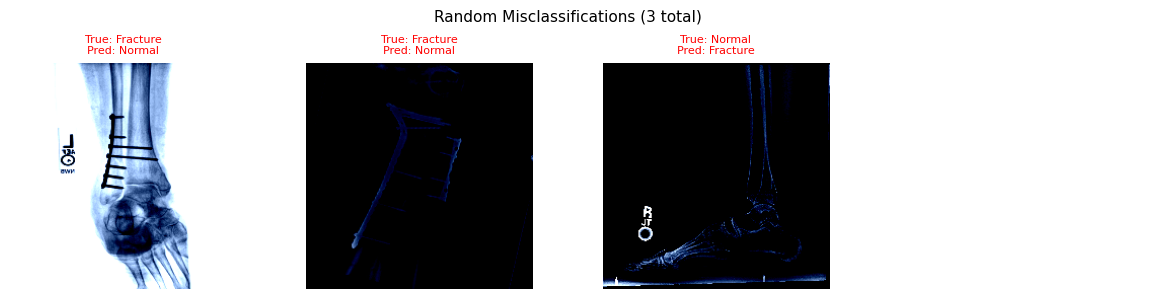

In [43]:
show_misclassifications(model=model_resnet, data_loader=dataloader_test, device=device, class_names=class_names, n=8)

The left image was likely misclassified because the model lacks training examples of surgical hardware, causing it to fail when encountering these metallic artifacts. The images on the right were misclassified due to extreme darkness and poor contrast, which obscure the bone structures needed for accurate feature detection. 

## Model Comparison and Conclusion

Training on a small dataset of 108 images presented significant challenges, requiring an iterative approach to achieve stable convergence.

Challenges: 
- High Instability: Initial experiments with a simple train/validation split resulted in highly volatile learning curves.
- Overfitting: The model frequently memorized training samples, causing a rapid decrease in training loss while validation loss fluctuated a lot.

To enhance robustness and generalization, we implemented the following:

- Advanced Data Augmentation: We expanded the pipeline with RandomResizedCrop, ColorJitter, and RandomVerticalFlip to artificially increase dataset diversity and reduce sensitivity to specific image features.
- 5-Fold Cross-Validation: Replacing the single-split approach with 5-fold cross-validation ensured that every image was used for validation, eliminating potential bias from individual splits.
- Hyperparameter Tuning: We reduced the learning rate from 0.001 to 0.0001. This smaller step size prevented the optimizer from overshooting the local minimum, resulting in smoother and more reliable convergence.

These improvements helped the model to learn from the small dataset.


#### Model Comparison:
While both architectures encountered challenges due to the small sample size, the VGG-16 model demonstrated better results by leveraging pre-trained weights to recognize low-level hierarchical features immediately.  This allowed for faster convergence and more stable learning curves compared to the custom ResNet, which required extensive training to extract features from scratch. Although the ResNet architecture produced promising test results, the substantial increase in computational time and the inherent instability during training highlight the limitations of building deep models without pre-trained foundations. Consequently, for datasets of this scale, transfer learning is the recommended approach, providing a robust, efficient, and more reliable pathway to high diagnostic accuracy compared to training an architecture from the ground up.